
**The Swin Pipeline & Architectural Ablation**

In [3]:
# ============================================================
# PART 1: INSTALL DEPENDENCIES & SETUP
# ============================================================

!pip install torch torchvision timm matplotlib scikit-learn seaborn tqdm pillow wandb -q

# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------
import torch
import torchvision
import timm
import os
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

# ------------------------------------------------------------
# Version info & environment check
# ------------------------------------------------------------
print("=" * 60)
print("ENVIRONMENT")
print("=" * 60)
print(f"Python       : {sys.version.split()[0]}")
print(f"PyTorch      : {torch.__version__}")
print(f"TorchVision  : {torchvision.__version__}")
print(f"timm         : {timm.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version : {torch.version.cuda}")
print("=" * 60)

# ------------------------------------------------------------
# Global configuration (single source of truth)
# ------------------------------------------------------------
CONFIG = {
    # ----- Dataset -----
    'dataset'        : 'eurosat',
    'data_root'      : './data',
    'num_classes'    : 10,
    'val_split'      : 0.20,          # fixed 80/20

    # ----- Optimization (must be IDENTICAL for baseline & ablation) -----
    'optimizer'      : 'AdamW',
    'lr'             : 5e-5,
    'weight_decay'   : 1e-4,
    'batch_size'     : 32,            # reduce to 16 only if OOM (apply to BOTH)
    'epochs'         : 30,
    'warmup_epochs'  : 5,
    'grad_clip'      : 1.0,

    # ----- Scheduler -----
    'scheduler'      : 'cosine_with_warmup',

    # ----- Input / augmentation -----
    'img_size'       : 224,
    'norm_mean'      : [0.485, 0.456, 0.406],
    'norm_std'       : [0.229, 0.224, 0.225],

    # ----- Reproducibility -----
    'seed_split'     : 42,            # data split & shuffling
    'seed_model'     : 123,           # model weight initialization

    # ----- Runtime -----
    'num_workers'    : 2,
    'device'         : 'cuda' if torch.cuda.is_available() else 'cpu',
    'use_amp'        : True,

    # ----- Logging -----
    'use_wandb'      : True,
    'wandb_project'  : 'swin_ablation',
    'log_dir'        : './logs',
    'plot_dir'       : './plots',
}

# ------------------------------------------------------------
# Reproducibility helpers
# ------------------------------------------------------------
def set_seed(seed: int):
    """Set all relevant seeds for reproducible runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Data split seed (used later when generating stratified split)
set_seed(CONFIG['seed_split'])

# ------------------------------------------------------------
# Directory setup
# ------------------------------------------------------------
os.makedirs(CONFIG['data_root'], exist_ok=True)
os.makedirs(CONFIG['log_dir'],   exist_ok=True)
os.makedirs(CONFIG['plot_dir'],  exist_ok=True)

print("\n Directories ready:")
print(f"   data  : {os.path.abspath(CONFIG['data_root'])}")
print(f"   logs  : {os.path.abspath(CONFIG['log_dir'])}")
print(f"   plots : {os.path.abspath(CONFIG['plot_dir'])}")

# ------------------------------------------------------------
# Optional: Weights & Biases initialization
# ------------------------------------------------------------
#*if CONFIG['use_wandb']:
    #import wandb
    #wandb.login()*/

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("CONFIG SUMMARY")
print("=" * 60)
for k, v in CONFIG.items():
    print(f"  {k:<16}: {v}")
print("=" * 60)
print("\n Part 1 complete — environment configured, seeds set, directories ready.")

ENVIRONMENT
Python       : 3.13.15
PyTorch      : 2.11.0+cu128
TorchVision  : 0.26.0+cu128
timm         : 1.0.29
CUDA Available: True
GPU          : Tesla T4
CUDA Version : 12.8

 Directories ready:
   data  : /content/data
   logs  : /content/logs
   plots : /content/plots

CONFIG SUMMARY
  dataset         : eurosat
  data_root       : ./data
  num_classes     : 10
  val_split       : 0.2
  optimizer       : AdamW
  lr              : 5e-05
  weight_decay    : 0.0001
  batch_size      : 32
  epochs          : 30
  warmup_epochs   : 5
  grad_clip       : 1.0
  scheduler       : cosine_with_warmup
  img_size        : 224
  norm_mean       : [0.485, 0.456, 0.406]
  norm_std        : [0.229, 0.224, 0.225]
  seed_split      : 42
  seed_model      : 123
  num_workers     : 2
  device          : cuda
  use_amp         : True
  use_wandb       : True
  wandb_project   : swin_ablation
  log_dir         : ./logs
  plot_dir        : ./plots

 Part 1 complete — environment configured, seeds set, d

In [4]:
# ============================================================
# PART 2: MOUNT GOOGLE DRIVE (For persistent storage)
# ============================================================

print(f"\n{'='*60}")
print(f"PART 2: Mounting Google Drive")
print(f"{'='*60}")

DRIVE_PATH = None

try:
    from google.colab import drive
    drive.mount('/content/drive')

    # Create folder structure in Drive
    DRIVE_PATH = '/content/drive/MyDrive/swin_ablation_results'
    !mkdir -p $DRIVE_PATH
    !mkdir -p $DRIVE_PATH/logs
    !mkdir -p $DRIVE_PATH/plots
    !mkdir -p $DRIVE_PATH/data

    print(f" Google Drive mounted successfully!")
    print(f" Results will be saved to: {DRIVE_PATH}")

    # Create a symlink for easy access
    !ln -sf $DRIVE_PATH /content/swin_ablation_drive

except ImportError:
    print(" Not running in Google Colab (skipping Drive mount)")
    print("   Results will be saved locally only")
except Exception as e:
    print(f" Could not mount Drive: {e}")
    print("   Results will be saved locally only")

print(f"\n{'='*60}")


PART 2: Mounting Google Drive
Mounted at /content/drive
 Google Drive mounted successfully!
 Results will be saved to: /content/drive/MyDrive/swin_ablation_results




PART 3: Loading eurosat Dataset

   This may take 2–5 minutes depending on internet speed


100%|██████████| 94.3M/94.3M [00:00<00:00, 134MB/s]


✅ EuroSAT loaded: 27000 images, 10 classes
   Classes: AnnualCrop, Forest, HerbaceousVegetation, Highway, Industrial, Pasture, PermanentCrop, Residential, River, SeaLake

 Stratified split (seed=42):
   Train:  21600 images
   Val  :   5400 images

   Train class counts (min/max): 1600 / 2400
   Val   class counts (min/max): 400 / 600

 Transform sanity check:
   train_subset uses: RandomResizedCrop ...
   val_subset   uses: Resize ...


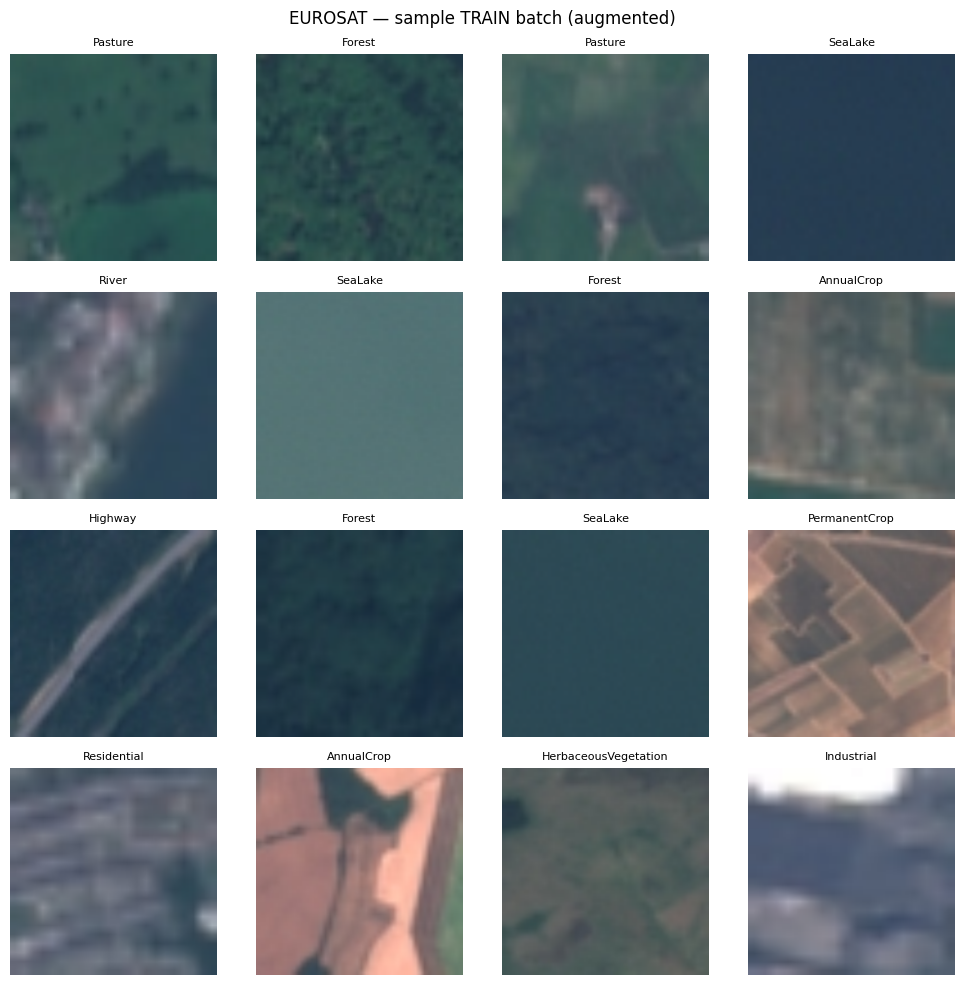


 Sample grid saved → ./plots/sample_train_batch.png

PART 3 COMPLETE
  Dataset        : eurosat
  Num classes    : 10
  Train samples  : 21600
  Val   samples  : 5400
  Batch size     : 32
  Train batches  : 675
  Val   batches  : 169
  Split seed     : 42
  Device         : cuda
 Data pipeline ready for training.


In [5]:
# ============================================================
# PART 3 (UPDATED): DATASET LOADING, STRATIFIED SPLIT, DATALOADERS,
#                   + 4x4 SAMPLE VISUALIZATION
# ============================================================

import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, ConcatDataset
from sklearn.model_selection import StratifiedShuffleSplit
from collections import Counter
import numpy as np
import os
import torch

print(f"\n{'='*60}")
print(f"PART 3: Loading {CONFIG['dataset']} Dataset")
print(f"{'='*60}")

# ------------------------------------------------------------
# 3.1  Transforms (fixed by assignment spec)
# ------------------------------------------------------------
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(CONFIG['img_size']),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=CONFIG['norm_mean'], std=CONFIG['norm_std']),
])

val_transform = transforms.Compose([
    # Deterministic eval transform (documented in report — NOT augmented)
    transforms.Resize(256),
    transforms.CenterCrop(CONFIG['img_size']),
    transforms.ToTensor(),
    transforms.Normalize(mean=CONFIG['norm_mean'], std=CONFIG['norm_std']),
])

# ------------------------------------------------------------
# 3.2  Load raw dataset TWICE (one handle per transform).
#      This prevents train-augmentation leakage into the val set.
# ------------------------------------------------------------

print("\n Downloading EuroSAT (RGB, ~270 MB)...")
print("   This may take 2–5 minutes depending on internet speed")

ds_train_handle = datasets.EuroSAT(
    root=CONFIG['data_root'], transform=train_transform, download=True
)
ds_val_handle = datasets.EuroSAT(
    root=CONFIG['data_root'], transform=val_transform, download=True
)

# Efficient label read (no image loading)
labels = np.array(
    ds_train_handle.labels if hasattr(ds_train_handle, 'labels')
    else ds_train_handle.targets
)
class_names = ds_train_handle.classes
CONFIG['num_classes'] = len(class_names)

print(f"✅ EuroSAT loaded: {len(ds_train_handle)} images, "
      f"{CONFIG['num_classes']} classes")
print(f"   Classes: {', '.join(class_names)}")


# ------------------------------------------------------------
# 3.3  Stratified 80/20 split  (seed = 42, fixed by assignment)
# ------------------------------------------------------------
sss = StratifiedShuffleSplit(
    n_splits=1,
    test_size=CONFIG['val_split'],
    random_state=CONFIG['seed_split'],
)
indices = np.arange(len(labels))
train_idx, val_idx = next(sss.split(indices, labels))

print(f"\n Stratified split (seed={CONFIG['seed_split']}):")
print(f"   Train: {len(train_idx):>6} images")
print(f"   Val  : {len(val_idx):>6} images")

train_counts = Counter(labels[train_idx].tolist())
val_counts   = Counter(labels[val_idx].tolist())
print(f"\n   Train class counts (min/max): "
      f"{min(train_counts.values())} / {max(train_counts.values())}")
print(f"   Val   class counts (min/max): "
      f"{min(val_counts.values())} / {max(val_counts.values())}")

# ------------------------------------------------------------
# 3.4  Build Subsets with CORRECT transforms
# ------------------------------------------------------------
train_subset = Subset(ds_train_handle, train_idx)   # train_transform
val_subset   = Subset(ds_val_handle,   val_idx)     # val_transform

print(f"\n Transform sanity check:")
print(f"   train_subset uses: "
      f"{train_subset.dataset.transform.transforms[0].__class__.__name__} ...")
print(f"   val_subset   uses: "
      f"{val_subset.dataset.transform.transforms[0].__class__.__name__} ...")

# ------------------------------------------------------------
# 3.5  DataLoaders (identical settings for baseline & ablation)
# ------------------------------------------------------------
train_loader = DataLoader(
    train_subset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=True,
    drop_last=True,
)

val_loader = DataLoader(
    val_subset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True,
)

# ------------------------------------------------------------
# 3.6  Sample grid visualization (4x4 = 16 images from TRAIN batch)
# ------------------------------------------------------------
import matplotlib.pyplot as plt

def denormalize(img_tensor):
    mean = torch.tensor(CONFIG['norm_mean']).view(3, 1, 1)
    std  = torch.tensor(CONFIG['norm_std']).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

imgs, lbls = next(iter(train_loader))
n_show = min(16, imgs.size(0))

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
axes = axes.flatten()

for ax, im, lb in zip(axes, imgs[:n_show], lbls[:n_show]):
    ax.imshow(denormalize(im).permute(1, 2, 0).numpy())
    ax.set_title(class_names[lb.item()], fontsize=8)
    ax.axis('off')

# Hide any unused subplots (in case batch < 16, shouldn't happen here)
for ax in axes[n_show:]:
    ax.axis('off')

plt.suptitle(f"{CONFIG['dataset'].upper()} — sample TRAIN batch (augmented)",
             fontsize=12)
plt.tight_layout()
sample_path = os.path.join(CONFIG['plot_dir'], 'sample_train_batch.png')
plt.savefig(sample_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n Sample grid saved → {sample_path}")

# ------------------------------------------------------------
# 3.7  Summary
# ------------------------------------------------------------
print(f"\n{'='*60}")
print("PART 3 COMPLETE")
print(f"{'='*60}")
print(f"  Dataset        : {CONFIG['dataset']}")
print(f"  Num classes    : {CONFIG['num_classes']}")
print(f"  Train samples  : {len(train_subset)}")
print(f"  Val   samples  : {len(val_subset)}")
print(f"  Batch size     : {CONFIG['batch_size']}")
print(f"  Train batches  : {len(train_loader)}")
print(f"  Val   batches  : {len(val_loader)}")
print(f"  Split seed     : {CONFIG['seed_split']}")
print(f"  Device         : {CONFIG['device']}")
print(f"{'='*60}")
print(" Data pipeline ready for training.")

In [6]:
# ============================================================
# PART 4 (BASELINE): Swin-Tiny with single linear head
# ============================================================

import torch
import torch.nn as nn
import timm

class BaselineSwinT(nn.Module):
    """Baseline Swin-Tiny: pretrained backbone + single linear classification head."""

    def __init__(self, num_classes: int):
        super().__init__()

        # 1) Pretrained backbone
        self.backbone = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=True,
            num_classes=0,
        )
        embed_dim = self.backbone.num_features     # 768 for Swin-Tiny

        # 2) Single linear classification head
        self.head = nn.Linear(embed_dim, num_classes)

        # 3) Init ONLY the new head — backbone stays pretrained
        nn.init.xavier_uniform_(self.head.weight)
        nn.init.zeros_(self.head.bias)

    def forward(self, x):
        feats = self.backbone(x)         # (B, 768)
        return self.head(feats)          # (B, num_classes)

    # ============================================================
    # Gradient-norm utility (matches "average gradient norm over
    # all parameters" required by the assignment).
    #   mode='l2'   -> global L2 norm  ||concat(grads)||_2   (default)
    #   mode='mean' -> mean of per-parameter L2 norms
    # Log mode='l2' as the primary metric (comparable to 1e3 threshold).
    # ============================================================
    @torch.no_grad()
    def get_grad_norm(self, mode: str = 'l2') -> float:
        grads = [p.grad.detach() for p in self.parameters() if p.grad is not None]
        if not grads:
            return 0.0
        if mode == 'l2':
            return torch.sqrt(sum(g.pow(2).sum() for g in grads)).item()
        elif mode == 'mean':
            return sum(g.norm(2).item() for g in grads) / len(grads)
        else:
            raise ValueError(f"Unknown mode: {mode}")


# ------------------------------------------------------------
# Build baseline with the FIXED model-init seed (123)
# ------------------------------------------------------------
print(f"\n{'='*60}")
print("PART 4: Building Baseline Swin-Tiny")
print(f"{'='*60}")

set_seed(CONFIG['seed_model'])          # seed = 123, per assignment

baseline_model = BaselineSwinT(
    num_classes=CONFIG['num_classes']
).to(CONFIG['device'])

# ------------------------------------------------------------
# Parameter counts (useful for the report)
# ------------------------------------------------------------
backbone_params = sum(p.numel() for p in baseline_model.backbone.parameters())
head_params     = sum(p.numel() for p in baseline_model.head.parameters())
total_params    = backbone_params + head_params

print(f"\n Baseline model built:")
print(f"   Architecture    : swin.tiny.patch4_window7_224")
print(f"   Pretrained      : True (ImageNet)")
print(f"   Backbone params : {backbone_params:,}")
print(f"   Head params     : {head_params:,}")
print(f"   Total params    : {total_params:,}")
print(f"   Num classes     : {CONFIG['num_classes']}")
print(f"   Device          : {CONFIG['device']}")
print(f"   Init seed       : {CONFIG['seed_model']}")

# ------------------------------------------------------------
# Sanity check: forward pass with a dummy batch
# ------------------------------------------------------------
with torch.no_grad():
    dummy = torch.randn(2, 3, CONFIG['img_size'], CONFIG['img_size']).to(CONFIG['device'])
    out = baseline_model(dummy)

print(f"\n Forward-pass sanity check:")
print(f"   Input  shape : {tuple(dummy.shape)}")
print(f"   Output shape : {tuple(out.shape)}   (expected: (2, {CONFIG['num_classes']}))")
assert out.shape == (2, CONFIG['num_classes']), \
    f"Shape mismatch! Got {tuple(out.shape)}"
print("    Output shape OK")

print(f"\n{'='*60}")
print("✅ Part 4 complete — baseline model ready.")
print(f"{'='*60}")


PART 4: Building Baseline Swin-Tiny


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            


 Baseline model built:
   Architecture    : swin.tiny.patch4_window7_224
   Pretrained      : True (ImageNet)
   Backbone params : 27,519,354
   Head params     : 7,690
   Total params    : 27,527,044
   Num classes     : 10
   Device          : cuda
   Init seed       : 123

 Forward-pass sanity check:
   Input  shape : (2, 3, 224, 224)
   Output shape : (2, 10)   (expected: (2, 10))
    Output shape OK

✅ Part 4 complete — baseline model ready.


In [7]:
# ============================================================
# PART 5: TRAINING FUNCTION (CONFIG-DRIVEN, PRE/POST-CLIP GRAD NORMS)
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.amp import GradScaler, autocast
from tqdm import tqdm
import time
import numpy as np
from sklearn.metrics import f1_score


def train_model(model, model_name, train_loader, val_loader):
    device = torch.device(CONFIG['device'])
    model  = model.to(device)

    # ---- Hyperparameters  ----
    EPOCHS         = CONFIG['epochs']
    LEARNING_RATE  = CONFIG['lr']
    WEIGHT_DECAY   = CONFIG['weight_decay']
    GRADIENT_CLIP  = CONFIG['grad_clip']
    WARMUP_EPOCHS  = CONFIG['warmup_epochs']
    USE_AMP        = CONFIG['use_amp']

    # ---- Loss / Optimizer ----
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(),
                            lr=LEARNING_RATE,
                            weight_decay=WEIGHT_DECAY)

    # ---- Scheduler: LinearLR warmup -> CosineAnnealingLR (PER BATCH) ----
    total_steps  = EPOCHS        * len(train_loader)
    warmup_steps = WARMUP_EPOCHS * len(train_loader)

    warmup_scheduler = LinearLR(optimizer, start_factor=0.1,
                                total_iters=warmup_steps)
    cosine_scheduler = CosineAnnealingLR(optimizer,
                                         T_max=max(1, total_steps - warmup_steps))
    scheduler = SequentialLR(optimizer,
                             [warmup_scheduler, cosine_scheduler],
                             milestones=[warmup_steps])

    scaler = GradScaler(enabled=USE_AMP)

    # ---- Metrics ----
    train_losses       = []
    val_losses         = []
    val_accuracies     = []
    raw_grad_norms     = []
    clipped_grad_norms = []
    val_f1_scores      = []
    lrs                = []

    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")
    print(f"Device        : {device}")
    print(f"Epochs        : {EPOCHS}")
    print(f"Batch size    : {CONFIG['batch_size']}")
    print(f"LR            : {LEARNING_RATE}")
    print(f"Weight decay  : {WEIGHT_DECAY}")
    print(f"Grad clip     : {GRADIENT_CLIP}")
    print(f"Warmup epochs : {WARMUP_EPOCHS}")
    print(f"AMP enabled   : {USE_AMP}")
    print(f"Train batches : {len(train_loader)}")
    print(f"Val   batches : {len(val_loader)}")
    print(f"{'='*60}\n")

    best_acc = 0.0
    best_path = f"{CONFIG['log_dir']}/{model_name}_best.pth"
    start_time = time.time()

    for epoch in range(EPOCHS):
        epoch_start = time.time()

        # ---------------- TRAIN ----------------
        model.train()
        running_loss = 0.0
        batch_raw_grads = []
        batch_clipped_grads = []

        progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
        for data, targets in progress:
            data    = data.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type='cuda' if device.type == 'cuda' else 'cpu',
                          dtype=torch.float16,
                          enabled=USE_AMP):
                outputs = model(data)
                loss    = criterion(outputs, targets)

            # 1) Backward (scaled if AMP)
            scaler.scale(loss).backward()

            # 2) Unscale so clipping + norm-reading see true gradients
            if USE_AMP:
                scaler.unscale_(optimizer)

            # 3) Log RAW (pre-clip) gradient norm
            raw_gn = model.get_grad_norm(mode='l2')
            if not np.isfinite(raw_gn):
                raw_gn = float('nan')   # keep visible in plots
            batch_raw_grads.append(raw_gn)

            # 4) Clip
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)

            # 5) Log POST-clip gradient norm
            clipped_gn = model.get_grad_norm(mode='l2')
            batch_clipped_grads.append(clipped_gn)

            # 6) Optimizer step + AMP update
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            running_loss += loss.item()
            progress.set_postfix({
                'loss'   : f"{loss.item():.4f}",
                'gn_raw' : f"{raw_gn:.3f}",
                'lr'     : f"{optimizer.param_groups[0]['lr']:.2e}",
            })

        avg_train_loss  = running_loss / len(train_loader)
        avg_raw_gn      = float(np.nanmean(batch_raw_grads))     if batch_raw_grads else 0.0
        avg_clipped_gn  = float(np.nanmean(batch_clipped_grads)) if batch_clipped_grads else 0.0

        train_losses.append(avg_train_loss)
        raw_grad_norms.append(avg_raw_gn)
        clipped_grad_norms.append(avg_clipped_gn)
        lrs.append(optimizer.param_groups[0]['lr'])

        # ---------------- VALIDATE ----------------
        model.eval()
        running_val_loss = 0.0
        correct = 0
        total   = 0
        all_targets, all_preds = [], []

        with torch.no_grad():
            for data, targets in val_loader:
                data    = data.to(device, non_blocking=True)
                targets = targets.to(device, non_blocking=True)

                with autocast(device_type='cuda' if device.type == 'cuda' else 'cpu',
                              dtype=torch.float16,
                              enabled=USE_AMP):
                    outputs = model(data)
                    loss    = criterion(outputs, targets)

                running_val_loss += loss.item()
                _, predicted = outputs.max(1)
                total   += targets.size(0)
                correct += predicted.eq(targets).sum().item()

                all_targets.extend(targets.cpu().numpy())
                all_preds.extend(predicted.cpu().numpy())

        avg_val_loss = running_val_loss / len(val_loader)
        val_acc      = correct / total
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        val_f1 = None
        if CONFIG['dataset'] == 'flowers102':
            val_f1 = f1_score(all_targets, all_preds, average='macro')
            val_f1_scores.append(val_f1)

        # ---------------- LOG EPOCH ----------------
        print(f"\nEpoch {epoch+1}/{EPOCHS}  (time {time.time()-epoch_start:.1f}s)")
        print(f"  Train Loss        : {avg_train_loss:.4f}")
        print(f"  Val   Loss        : {avg_val_loss:.4f}")
        print(f"  Val   Acc (top-1) : {val_acc:.4f}")
        if val_f1 is not None:
            print(f"  Val   F1 (macro)  : {val_f1:.4f}")
        print(f"  Grad Norm (raw)   : {avg_raw_gn:.4e}   <- compare to 1e3")
        print(f"  Grad Norm (clip)  : {avg_clipped_gn:.4e}")
        print(f"  LR                : {optimizer.param_groups[0]['lr']:.2e}")
        print("-" * 60)

        # ---------------- CHECKPOINT ----------------
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), best_path)
            print(f" New best (acc={best_acc:.4f}) → {best_path}")

    # ---- Save final weights ----
    final_path = f"{CONFIG['log_dir']}/{model_name}_final.pth"
    torch.save(model.state_dict(), final_path)

    # ---- Reload best and re-evaluate (report the BEST metrics) ----
    model.load_state_dict(torch.load(best_path, map_location=device))
    model.eval()
    correct, total = 0, 0
    all_targets, all_preds = [], []
    with torch.no_grad():
        for data, targets in val_loader:
            data    = data.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            with autocast(device_type='cuda' if device.type == 'cuda' else 'cpu',
                          dtype=torch.float16,
                          enabled=USE_AMP):
                outputs = model(data)
            _, predicted = outputs.max(1)
            total   += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            all_targets.extend(targets.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
    best_acc_reloaded = correct / total
    best_f1_reloaded = (f1_score(all_targets, all_preds, average='macro')
                        if CONFIG['dataset'] == 'flowers102' else None)

    elapsed = time.time() - start_time
    print(f"\n{'='*60}")
    print(f" {model_name} — training complete")
    print(f"   Best Val Acc (during training) : {best_acc:.4f}")
    print(f"   Best Val Acc (reloaded)        : {best_acc_reloaded:.4f}")
    if best_f1_reloaded is not None:
        print(f"   Best Val F1  (reloaded)        : {best_f1_reloaded:.4f}")
    print(f"   Total time                     : {elapsed//60:.0f}m {elapsed%60:.0f}s")
    print(f"{'='*60}")

    return {
        'model_name'         : model_name,
        'train_losses'       : train_losses,
        'val_losses'         : val_losses,
        'val_accuracies'     : val_accuracies,
        'raw_grad_norms'     : raw_grad_norms,
        'clipped_grad_norms' : clipped_grad_norms,
        'val_f1_scores'      : val_f1_scores if val_f1_scores else None,
        'lrs'                : lrs,
        'best_acc'           : best_acc_reloaded,
        'best_f1'            : best_f1_reloaded,
        'elapsed_sec'        : elapsed,
    }


print(" Training function ready (CONFIG-driven, pre/post-clip grad norms logged).")

 Training function ready (CONFIG-driven, pre/post-clip grad norms logged).


In [8]:
# ============================================================
# PART 6: TRAIN BASELINE MODEL
# ============================================================

print(f"\n{'='*60}")
print(f"PART 7: Training Baseline Model")
print(f"{'='*60}")

# ---- GPU info ----
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory  : {props.total_memory / 1e9:.2f} GB")
    torch.cuda.empty_cache()
else:
    print("Running on CPU (slow — expect long epoch times)")

print(f"Batch size  : {CONFIG['batch_size']}")
print(f"Device      : {CONFIG['device']}")
print(f"{'='*60}")

def make_loaders(bs: int):
    tl = DataLoader(train_subset, batch_size=bs, shuffle=True,
                    num_workers=CONFIG['num_workers'],
                    pin_memory=True, drop_last=True)
    vl = DataLoader(val_subset, batch_size=bs, shuffle=False,
                    num_workers=CONFIG['num_workers'],
                    pin_memory=True)
    return tl, vl


CONFIG['oom_triggered'] = False

if torch.cuda.is_available():
    try:
        probe = torch.randn(CONFIG['batch_size'], 3,
                            CONFIG['img_size'], CONFIG['img_size'],
                            device=CONFIG['device'])
        with torch.no_grad():
            _ = baseline_model(probe)
        del probe
        torch.cuda.empty_cache()
        print(f" Forward-pass memory probe OK at bs={CONFIG['batch_size']}")
    except RuntimeError as e:
        if 'out of memory' in str(e).lower():
            new_bs = CONFIG['batch_size'] // 2
            print(f" OOM at bs={CONFIG['batch_size']} → reducing to {new_bs}")
            print(f"   (the SAME batch size will be used for the ablation run)")
            CONFIG['batch_size']  = new_bs
            CONFIG['oom_triggered'] = True
            train_loader, val_loader = make_loaders(CONFIG['batch_size'])
            torch.cuda.empty_cache()
        else:
            raise

# ------------------------------------------------------------
# Train baseline
# ------------------------------------------------------------
baseline_results = train_model(
    model        = baseline_model,
    model_name   = 'baseline',
    train_loader = train_loader,
    val_loader   = val_loader,
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print(f"\n Baseline Results Summary")
print(f"{'-'*50}")
print(f"  Best Val Acc (reloaded) : {baseline_results['best_acc']:.4f}")
print(f"  Last Val Acc            : {baseline_results['val_accuracies'][-1]:.4f}")
print(f"  Last Val Loss           : {baseline_results['val_losses'][-1]:.4f}")
print(f"  Raw grad norm (epoch 1) : {baseline_results['raw_grad_norms'][0]:.4e}")
print(f"  Raw grad norm (last)    : {baseline_results['raw_grad_norms'][-1]:.4e}")
print(f"  Max raw grad norm       : {np.nanmax(baseline_results['raw_grad_norms']):.4e}")
if baseline_results['val_f1_scores'] is not None:
    print(f"  Best Val F1 (macro)     : {baseline_results['best_f1']:.4f}")
print(f"  OOM triggered?          : {CONFIG['oom_triggered']}")
print(f"  Batch size used         : {CONFIG['batch_size']}")
print(f"  Total training time     : {baseline_results['elapsed_sec']//60:.0f}m "
      f"{baseline_results['elapsed_sec']%60:.0f}s")
print(f"{'-'*50}")

# ------------------------------------------------------------
# Save results dict to disk (for later plotting / report)
# ------------------------------------------------------------
import pickle, os
results_path = os.path.join(CONFIG['log_dir'], 'baseline_results.pkl')
with open(results_path, 'wb') as f:
    pickle.dump(baseline_results, f)
print(f" Saved baseline results → {results_path}")

# Free GPU memory before building the ablation
del baseline_model
torch.cuda.empty_cache()
print(" Freed baseline model from GPU (weights saved to logs/)")


PART 7: Training Baseline Model
GPU         : Tesla T4
GPU Memory  : 15.64 GB
Batch size  : 32
Device      : cuda
 Forward-pass memory probe OK at bs=32

Training: baseline
Device        : cuda
Epochs        : 30
Batch size    : 32
LR            : 5e-05
Weight decay  : 0.0001
Grad clip     : 1.0
Warmup epochs : 5
AMP enabled   : True
Train batches : 675
Val   batches : 169



Epoch 1/30: 100%|██████████| 675/675 [02:15<00:00,  4.97it/s, loss=0.0689, gn_raw=8.688, lr=1.40e-05]



Epoch 1/30  (time 150.0s)
  Train Loss        : 0.5591
  Val   Loss        : 0.1573
  Val   Acc (top-1) : 0.9461
  Grad Norm (raw)   : 2.3111e+01   <- compare to 1e3
  Grad Norm (clip)  : 1.0000e+00
  LR                : 1.40e-05
------------------------------------------------------------
 New best (acc=0.9461) → ./logs/baseline_best.pth


Epoch 2/30: 100%|██████████| 675/675 [02:20<00:00,  4.82it/s, loss=0.1489, gn_raw=18.913, lr=2.30e-05]



Epoch 2/30  (time 154.4s)
  Train Loss        : 0.2313
  Val   Loss        : 0.0915
  Val   Acc (top-1) : 0.9674
  Grad Norm (raw)   : 2.1585e+01   <- compare to 1e3
  Grad Norm (clip)  : 1.0000e+00
  LR                : 2.30e-05
------------------------------------------------------------
 New best (acc=0.9674) → ./logs/baseline_best.pth


...


Epoch 28/30  (time 153.8s)
  Train Loss        : 0.0532
  Val   Loss        : 0.0479
  Val   Acc (top-1) : 0.9907
  Grad Norm (raw)   : 4.3191e+00   <- compare to 1e3
  Grad Norm (clip)  : 7.0011e-01
  LR                : 7.85e-07
------------------------------------------------------------


Epoch 29/30: 100%|██████████| 675/675 [02:19<00:00,  4.83it/s, loss=0.0016, gn_raw=0.222, lr=1.97e-07]



Epoch 29/30  (time 154.1s)
  Train Loss        : 0.0486
  Val   Loss        : 0.0489
  Val   Acc (top-1) : 0.9909
  Grad Norm (raw)   : 4.4147e+00   <- compare to 1e3
  Grad Norm (clip)  : 7.1762e-01
  LR                : 1.97e-07
------------------------------------------------------------


Epoch 30/30: 100%|██████████| 675/675 [02:19<00:00,  4.83it/s, loss=0.0006, gn_raw=0.042, lr=0.00e+00]



Epoch 30/30  (time 154.0s)
  Train Loss        : 0.0517
  Val   Loss        : 0.0489
  Val   Acc (top-1) : 0.9904
  Grad Norm (raw)   : 4.3115e+00   <- compare to 1e3
  Grad Norm (clip)  : 7.0115e-01
  LR                : 0.00e+00
------------------------------------------------------------

 baseline — training complete
   Best Val Acc (during training) : 0.9913
   Best Val Acc (reloaded)        : 0.9913
   Total time                     : 77m 24s

 Baseline Results Summary
--------------------------------------------------
  Best Val Acc (reloaded) : 0.9913
  Last Val Acc            : 0.9904
  Last Val Loss           : 0.0489
  Raw grad norm (epoch 1) : 2.3111e+01
  Raw grad norm (last)    : 4.3115e+00
  Max raw grad norm       : 2.3111e+01
  OOM triggered?          : False
  Batch size used         : 32
  Total training time     : 77m 24s
--------------------------------------------------
 Saved baseline results → ./logs/baseline_results.pkl
 Freed baseline model from GPU (weights 

In [9]:
# ============================================================
# PART 7 (ABLATION): Global attention every other block + SiLU
# ============================================================
import torch
import torch.nn as nn
import timm

# ---- Custom global attention (matches Swin's WindowAttention API) ----
class GlobalAttention(nn.Module):
    """Full spatial attention over all tokens (no windowing)."""
    def __init__(self, dim, num_heads, qkv_bias=True, proj_bias=True,
                 attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        assert dim % num_heads == 0
        self.dim       = dim
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5

        self.qkv       = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj      = nn.Linear(dim, dim, bias=proj_bias)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x, mask=None, *args, **kwargs):
        # x: (B, N, C)   ignore mask (global attention doesn't need it)
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)               # (3, B, H, N, Dh)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, H, N, N)
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x


# ---- Ablation model ----
class AblationSwinT(nn.Module):
    """Swin-Tiny with:
       (M1) Global attention in every other block (article-critique improvement)
       (M2) SiLU activation instead of GELU
    """

    def __init__(self, num_classes: int, global_every: int = 2):
        super().__init__()

        # Dotted model name (matches assignment spec; avoids "Unknown model")
        self.backbone = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=True,
            num_classes=0,
        )
        embed_dim = self.backbone.num_features     # 768

        # ---- Modification M2: swap GELU -> SiLU inside the backbone ----
        silu_count = self._replace_gelu_with_silu(self.backbone)
        print(f"  GELU -> SiLU replacements in backbone: {silu_count}")

        # ---- Modification M1: global attention every `global_every` blocks ----
        modified = self._inject_global_attention(self.backbone, every=global_every)
        print(f"  Blocks switched to global attention: {modified}")

        # ---- Head: EXACTLY the same as baseline (single Linear) ----
        self.head = nn.Linear(embed_dim, num_classes)
        nn.init.xavier_uniform_(self.head.weight)
        nn.init.zeros_(self.head.bias)

    # ---------------------------------------------------------
    @staticmethod
    def _replace_gelu_with_silu(root: nn.Module) -> int:
        count = 0
        for name, child in root.named_children():
            if isinstance(child, nn.GELU):
                setattr(root, name, nn.SiLU())
                count += 1
            else:
                count += AblationSwinT._replace_gelu_with_silu(child)
        return count

    # ---------------------------------------------------------
    @staticmethod
    def _inject_global_attention(backbone: nn.Module, every: int = 2) -> int:
        """
        Iterate Swin stages deterministically; replace attn of every
        `every`-th block (indices 0, 2, 4, ...) with GlobalAttention.
        Reads dim / num_heads directly from the existing module.
        """
        count = 0
        for stage_idx, layer in enumerate(backbone.layers):
            for block_idx, block in enumerate(layer.blocks):
                if block_idx % every != 0:
                    continue

                old_attn = block.attn
                # Reliable introspection of dim / num_heads
                dim       = old_attn.qkv.in_features
                num_heads = old_attn.num_heads
                qkv_bias  = old_attn.qkv.bias is not None
                proj_bias = old_attn.proj.bias is not None

                block.attn = GlobalAttention(
                    dim=dim,
                    num_heads=num_heads,
                    qkv_bias=qkv_bias,
                    proj_bias=proj_bias,
                    attn_drop=0.0,
                    proj_drop=0.0,
                )
                count += 1
        return count

    # ---------------------------------------------------------
    def forward(self, x):
        feats = self.backbone(x)          # (B, 768)
        return self.head(feats)

    @torch.no_grad()
    def get_grad_norm(self, mode: str = 'l2') -> float:
        grads = [p.grad.detach() for p in self.parameters() if p.grad is not None]
        if not grads:
            return 0.0
        if mode == 'l2':
            return torch.sqrt(sum(g.pow(2).sum() for g in grads)).item()
        if mode == 'mean':
            return sum(g.norm(2).item() for g in grads) / len(grads)
        raise ValueError(mode)


# ------------------------------------------------------------
# Build ablation with the SAME model-init seed as baseline
# ------------------------------------------------------------
print(f"\n{'='*60}")
print("PART 8: Building Ablation Swin-Tiny")
print(f"{'='*60}")
print("Modifications:")
print("  M1: global attention in every other block (article critique)")
print("  M2: SiLU instead of GELU")

set_seed(CONFIG['seed_model'])          # 123 — matches baseline head init

ablation_model = AblationSwinT(
    num_classes=CONFIG['num_classes'],
    global_every=2,
).to(CONFIG['device'])

# ---- Parameter counts ----
backbone_params_abl = sum(p.numel() for p in ablation_model.backbone.parameters())
head_params_abl     = sum(p.numel() for p in ablation_model.head.parameters())
total_params_abl    = backbone_params_abl + head_params_abl

print(f"\n📊 Ablation model statistics:")
print(f"  Backbone params : {backbone_params_abl:,}")
print(f"  Head params     : {head_params_abl:,}")
print(f"  Total params    : {total_params_abl:,}")
print(f"  Baseline total  : {total_params:,}  (from Part 5)")
print(f"  Δ params        : {total_params_abl - total_params:,}")

# ---- Forward-pass shape sanity check ----
with torch.no_grad():
    dummy = torch.randn(2, 3, CONFIG['img_size'], CONFIG['img_size'],
                        device=CONFIG['device'])
    out = ablation_model(dummy)
print(f"\n Forward-pass sanity check:")
print(f"  Input  : {tuple(dummy.shape)}")
print(f"  Output : {tuple(out.shape)}")
assert out.shape == (2, CONFIG['num_classes'])
print("   Output shape OK")

print(f"\n Ablation model ready.")


PART 8: Building Ablation Swin-Tiny
Modifications:
  M1: global attention in every other block (article critique)
  M2: SiLU instead of GELU
  GELU -> SiLU replacements in backbone: 12
  Blocks switched to global attention: 6

📊 Ablation model statistics:
  Backbone params : 27,507,693
  Head params     : 7,690
  Total params    : 27,515,383
  Baseline total  : 27,527,044  (from Part 5)
  Δ params        : -11,661

 Forward-pass sanity check:
  Input  : (2, 3, 224, 224)
  Output : (2, 10)
   Output shape OK

 Ablation model ready.


In [10]:
# ============================================================
# PART 8: TRAIN ABLATION MODEL
# ============================================================

print(f"\n{'='*60}")
print(f"PART 8: Training Ablation Model")
print(f"{'='*60}")
print(f" Identical hyperparameters to baseline (from CONFIG)")
print(f" Only architectural change: M1 (global attn) + M2 (SiLU)")
print(f"{'='*60}")

# ---- Sanity: batch size parity ----
print(f"Batch size (should be same as baseline): {CONFIG['batch_size']}")
print(f"OOM triggered during baseline?         : {CONFIG['oom_triggered']}")
assert CONFIG['batch_size'] == 32 or CONFIG['oom_triggered'], \
    "Batch size changed but no OOM was recorded — parity broken!"

# ---- Rebuild loaders to guarantee settings match Part 7 ----
train_loader, val_loader = make_loaders(CONFIG['batch_size'])
print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")

# ---- Free any leftover memory ----
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

# ---- Train ablation ----
ablation_results = train_model(
    model        = ablation_model,
    model_name   = 'ablation',
    train_loader = train_loader,
    val_loader   = val_loader,
)

# ---- Summary ----
print(f"\n Ablation Results Summary")
print(f"{'-'*50}")
print(f"  Best Val Acc (reloaded) : {ablation_results['best_acc']:.4f}")
print(f"  Last Val Acc            : {ablation_results['val_accuracies'][-1]:.4f}")
print(f"  Last Val Loss           : {ablation_results['val_losses'][-1]:.4f}")
print(f"  Raw grad norm (epoch 1) : {ablation_results['raw_grad_norms'][0]:.4e}")
print(f"  Raw grad norm (last)    : {ablation_results['raw_grad_norms'][-1]:.4e}")
print(f"  Max raw grad norm       : {np.nanmax(ablation_results['raw_grad_norms']):.4e}")
print(f"  Clipped grad norm (mid) : {ablation_results['clipped_grad_norms'][len(ablation_results['clipped_grad_norms'])//2]:.4e}")
if ablation_results['val_f1_scores'] is not None:
    print(f"  Best Val F1 (macro)     : {ablation_results['best_f1']:.4f}")
print(f"  OOM triggered?          : {CONFIG['oom_triggered']}")
print(f"  Batch size used         : {CONFIG['batch_size']}")
print(f"  Total training time     : {ablation_results['elapsed_sec']//60:.0f}m "
      f"{ablation_results['elapsed_sec']%60:.0f}s")
print(f"{'-'*50}")

# ---- Save results dict for plotting ----
import pickle, os
results_path = os.path.join(CONFIG['log_dir'], 'ablation_results.pkl')
with open(results_path, 'wb') as f:
    pickle.dump(ablation_results, f)
print(f" Saved ablation results → {results_path}")

# ---- Free GPU ----
del ablation_model
torch.cuda.empty_cache()
print("Freed ablation model from GPU (weights saved to logs/)")


PART 8: Training Ablation Model
 Identical hyperparameters to baseline (from CONFIG)
 Only architectural change: M1 (global attn) + M2 (SiLU)
Batch size (should be same as baseline): 32
OOM triggered during baseline?         : False
Train batches : 675
Val   batches : 169

Training: ablation
Device        : cuda
Epochs        : 30
Batch size    : 32
LR            : 5e-05
Weight decay  : 0.0001
Grad clip     : 1.0
Warmup epochs : 5
AMP enabled   : True
Train batches : 675
Val   batches : 169



Epoch 1/30: 100%|██████████| 675/675 [02:20<00:00,  4.79it/s, loss=0.9224, gn_raw=38.567, lr=1.40e-05]



Epoch 1/30  (time 154.7s)
  Train Loss        : 1.4055
  Val   Loss        : 0.6972
  Val   Acc (top-1) : 0.7537
  Grad Norm (raw)   : 3.1940e+01   <- compare to 1e3
  Grad Norm (clip)  : 1.0000e+00
  LR                : 1.40e-05
------------------------------------------------------------
 New best (acc=0.7537) → ./logs/ablation_best.pth


Epoch 2/30: 100%|██████████| 675/675 [02:24<00:00,  4.66it/s, loss=0.3803, gn_raw=33.168, lr=2.30e-05]



Epoch 2/30  (time 158.6s)
  Train Loss        : 0.7058
  Val   Loss        : 0.3354
  Val   Acc (top-1) : 0.8800
  Grad Norm (raw)   : 4.5423e+01   <- compare to 1e3
  Grad Norm (clip)  : 1.0000e+00
  LR                : 2.30e-05
------------------------------------------------------------
 New best (acc=0.8800) → ./logs/ablation_best.pth


...


Epoch 28/30  (time 153.7s)
  Train Loss        : 0.0795
  Val   Loss        : 0.0558
  Val   Acc (top-1) : 0.9856
  Grad Norm (raw)   : 8.2260e+00   <- compare to 1e3
  Grad Norm (clip)  : 9.1570e-01
  LR                : 7.85e-07
------------------------------------------------------------


Epoch 29/30: 100%|██████████| 675/675 [02:19<00:00,  4.82it/s, loss=0.0100, gn_raw=1.500, lr=1.97e-07]



Epoch 29/30  (time 154.0s)
  Train Loss        : 0.0849
  Val   Loss        : 0.0566
  Val   Acc (top-1) : 0.9850
  Grad Norm (raw)   : 8.6210e+00   <- compare to 1e3
  Grad Norm (clip)  : 9.1831e-01
  LR                : 1.97e-07
------------------------------------------------------------


Epoch 30/30: 100%|██████████| 675/675 [02:19<00:00,  4.85it/s, loss=0.0051, gn_raw=3.217, lr=0.00e+00]



Epoch 30/30  (time 153.0s)
  Train Loss        : 0.0752
  Val   Loss        : 0.0565
  Val   Acc (top-1) : 0.9854
  Grad Norm (raw)   : 7.9357e+00   <- compare to 1e3
  Grad Norm (clip)  : 8.9852e-01
  LR                : 0.00e+00
------------------------------------------------------------

 ablation — training complete
   Best Val Acc (during training) : 0.9869
   Best Val Acc (reloaded)        : 0.9869
   Total time                     : 77m 27s

 Ablation Results Summary
--------------------------------------------------
  Best Val Acc (reloaded) : 0.9869
  Last Val Acc            : 0.9854
  Last Val Loss           : 0.0565
  Raw grad norm (epoch 1) : 3.1940e+01
  Raw grad norm (last)    : 7.9357e+00
  Max raw grad norm       : 4.5423e+01
  Clipped grad norm (mid) : 9.9151e-01
  OOM triggered?          : False
  Batch size used         : 32
  Total training time     : 77m 27s
--------------------------------------------------
 Saved ablation results → ./logs/ablation_results.pkl
F


PART 10: Results Comparison

 SUMMARY STATISTICS
------------------------------------------------------------

 BASELINE
  Best Val Acc (reloaded) : 0.9913
  Last Val Acc            : 0.9904
  Last Val Loss           : 0.0489
  Raw grad norm — max     : 2.3111e+01
  Raw grad norm — mean    : 8.6740e+00
  Raw grad norm — min     : 4.3115e+00
  Raw grad norm — epoch 1 : 2.3111e+01
  Clipped grad norm — mean: 8.8410e-01
  Training time           : 77m 24s

 ABLATION
  Best Val Acc (reloaded) : 0.9869
  Last Val Acc            : 0.9854
  Last Val Loss           : 0.0565
  Raw grad norm — max     : 4.5423e+01
  Raw grad norm — mean    : 1.5709e+01
  Raw grad norm — min     : 7.9357e+00
  Raw grad norm — epoch 1 : 3.1940e+01
  Clipped grad norm — mean: 9.7244e-01
  Training time           : 77m 27s

 GRADIENT STABILITY ANALYSIS (threshold = 1e3)
------------------------------------------------------------
  Baseline : max raw = 2.3111e+01   well below 1e3
            clipping was applied bu

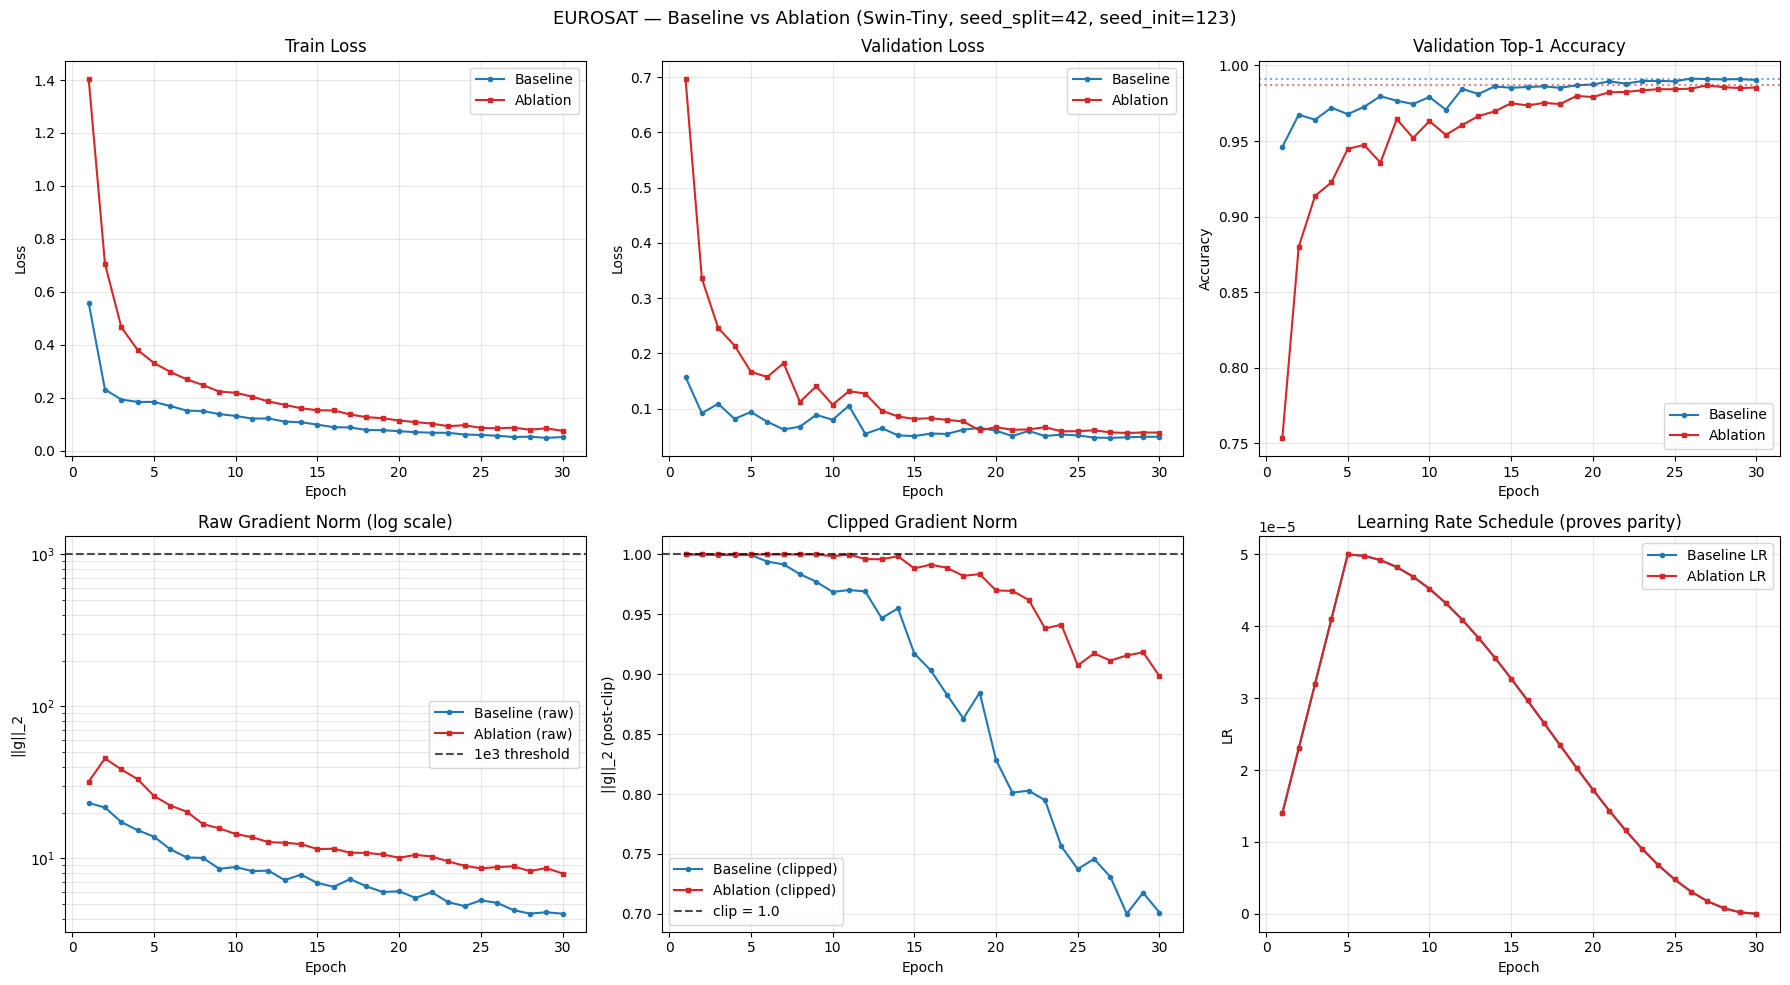


 Comparison figure saved → ./plots/comparison.png

 HYPERPARAMETER PARITY CHECK
------------------------------------------------------------
  optimizer     : AdamW
  lr            : 5e-05
  weight_decay  : 0.0001
  batch_size    : 32
  epochs        : 30
  warmup_epochs : 5
  img_size      : 224
  grad_clip     : 1.0
  seed_split    : 42
  seed_model    : 123
  scheduler     : CosineAnnealingLR with 5-epoch LinearLR warmup
  oom_triggered : False

 Part 9 complete.


In [11]:
# ============================================================
# PART 9: COMPARE BASELINE VS ABLATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import os

print(f"\n{'='*60}")
print(f"PART 10: Results Comparison")
print(f"{'='*60}")

# ------------------------------------------------------------
# 9.1  Summary statistics
# ------------------------------------------------------------
def summarize(name, r, color=""):
    raw = np.array(r['raw_grad_norms'], dtype=float)
    clip = np.array(r['clipped_grad_norms'], dtype=float)
    print(f"\n{color}{name}")
    print(f"  Best Val Acc (reloaded) : {r['best_acc']:.4f}")
    print(f"  Last Val Acc            : {r['val_accuracies'][-1]:.4f}")
    print(f"  Last Val Loss           : {r['val_losses'][-1]:.4f}")
    print(f"  Raw grad norm — max     : {np.nanmax(raw):.4e}")
    print(f"  Raw grad norm — mean    : {np.nanmean(raw):.4e}")
    print(f"  Raw grad norm — min     : {np.nanmin(raw):.4e}")
    print(f"  Raw grad norm — epoch 1 : {raw[0]:.4e}")
    print(f"  Clipped grad norm — mean: {np.nanmean(clip):.4e}")
    if r['val_f1_scores'] is not None:
        print(f"  Best Val F1 (macro)     : {r['best_f1']:.4f}")
    print(f"  Training time           : {r['elapsed_sec']//60:.0f}m "
          f"{r['elapsed_sec']%60:.0f}s")

print(f"\n SUMMARY STATISTICS")
print("-"*60)
summarize(" BASELINE", baseline_results)
summarize(" ABLATION", ablation_results)

# ------------------------------------------------------------
# 9.2  Gradient-stability analysis (10^3 threshold)
# ------------------------------------------------------------
print(f"\n GRADIENT STABILITY ANALYSIS (threshold = 1e3)")
print("-"*60)

for label, r in [('Baseline', baseline_results), ('Ablation', ablation_results)]:
    raw       = np.array(r['raw_grad_norms'], dtype=float)
    max_raw   = np.nanmax(raw)
    exceeded  = max_raw > 1e3
    print(f"  {label:<9}: max raw = {max_raw:.4e}  "
          f"{' EXCEEDED 1e3' if exceeded else ' well below 1e3'}")
    if exceeded:
        epochs_over = int(np.sum(raw > 1e3))
        print(f"            {epochs_over} epochs above 1e3 → "
              f"clipping was actively rescuing training")
    else:
        print(f"            clipping was applied but not needed to prevent instability")

# ------------------------------------------------------------
# 9.3  Hypothesis analysis
# ------------------------------------------------------------
print(f"\n HYPOTHESIS ANALYSIS")
print("-"*60)
print("Hypothesis: global attention in every other block + SiLU")
print("            will improve or match baseline performance.\n")

delta = ablation_results['best_acc'] - baseline_results['best_acc']
delta_pct = delta * 100

if abs(delta) < 0.002:
    print(f"    Effectively TIED (Δ = {delta_pct:+.2f}%)")
    print(f"     The modification was neutral w.r.t. accuracy.")
elif delta > 0:
    print(f"   Hypothesis SUPPORTED (Δ = {delta_pct:+.2f}%)")
    print(f"     Global attention + SiLU improved accuracy.")
else:
    print(f"   Hypothesis REJECTED (Δ = {delta_pct:+.2f}%)")
    print(f"     Global attention + SiLU did not improve accuracy.")
    print(f"     Candidate explanations:")
    print(f"       • Global attention removes Swin's locality prior")
    print(f"       • SiLU swap without LR retuning is often neutral/harmful")
    print(f"       • EuroSAT is texture-dominated → locality helps")
    print(f"     (A well-documented negative result is a valid outcome.)")

# ------------------------------------------------------------
# 9.4  Figures
# ------------------------------------------------------------
plot_dir = CONFIG['plot_dir']
os.makedirs(plot_dir, exist_ok=True)

epochs = np.arange(1, CONFIG['epochs'] + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# (1) Train loss
axes[0].plot(epochs, baseline_results['train_losses'],
             '-o', ms=3, color='tab:blue',  label='Baseline')
axes[0].plot(epochs, ablation_results['train_losses'],
             '-s', ms=3, color='tab:red',   label='Ablation')
axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3); axes[0].legend()

# (2) Val loss
axes[1].plot(epochs, baseline_results['val_losses'],
             '-o', ms=3, color='tab:blue',  label='Baseline')
axes[1].plot(epochs, ablation_results['val_losses'],
             '-s', ms=3, color='tab:red',   label='Ablation')
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].grid(alpha=0.3); axes[1].legend()

# (3) Val accuracy (top-1)
axes[2].plot(epochs, baseline_results['val_accuracies'],
             '-o', ms=3, color='tab:blue',  label='Baseline')
axes[2].plot(epochs, ablation_results['val_accuracies'],
             '-s', ms=3, color='tab:red',   label='Ablation')
axes[2].axhline(baseline_results['best_acc'], color='tab:blue',
                ls=':', alpha=0.6)
axes[2].axhline(ablation_results['best_acc'], color='tab:red',
                ls=':', alpha=0.6)
axes[2].set_title('Validation Top-1 Accuracy')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy')
axes[2].grid(alpha=0.3); axes[2].legend()

# (4) Raw gradient norm — LOG SCALE, with 1e3 threshold
raw_b = np.array(baseline_results['raw_grad_norms'], dtype=float)
raw_a = np.array(ablation_results['raw_grad_norms'], dtype=float)
axes[3].plot(epochs, raw_b, '-o', ms=3, color='tab:blue', label='Baseline (raw)')
axes[3].plot(epochs, raw_a, '-s', ms=3, color='tab:red',  label='Ablation (raw)')
axes[3].axhline(1e3, color='black', ls='--', alpha=0.7, label='1e3 threshold')
axes[3].set_yscale('log')
axes[3].set_title('Raw Gradient Norm (log scale)')
axes[3].set_xlabel('Epoch'); axes[3].set_ylabel('||g||_2')
axes[3].grid(alpha=0.3, which='both'); axes[3].legend()

# (5) Clipped gradient norm (proves clipping active)
clip_b = np.array(baseline_results['clipped_grad_norms'], dtype=float)
clip_a = np.array(ablation_results['clipped_grad_norms'], dtype=float)
axes[4].plot(epochs, clip_b, '-o', ms=3, color='tab:blue', label='Baseline (clipped)')
axes[4].plot(epochs, clip_a, '-s', ms=3, color='tab:red',  label='Ablation (clipped)')
axes[4].axhline(CONFIG['grad_clip'], color='black', ls='--', alpha=0.7,
                label=f"clip = {CONFIG['grad_clip']}")
axes[4].set_title('Clipped Gradient Norm')
axes[4].set_xlabel('Epoch'); axes[4].set_ylabel('||g||_2 (post-clip)')
axes[4].grid(alpha=0.3); axes[4].legend()

# (6) Learning rate (proves scheduler parity)
axes[5].plot(epochs, baseline_results['lrs'],
             '-o', ms=3, color='tab:blue',  label='Baseline LR')
axes[5].plot(epochs, ablation_results['lrs'],
             '-s', ms=3, color='tab:red',   label='Ablation LR')
axes[5].set_title('Learning Rate Schedule (proves parity)')
axes[5].set_xlabel('Epoch'); axes[5].set_ylabel('LR')
axes[5].grid(alpha=0.3); axes[5].legend()

plt.suptitle(
    f"{CONFIG['dataset'].upper()} — Baseline vs Ablation "
    f"(Swin-Tiny, seed_split={CONFIG['seed_split']}, seed_init={CONFIG['seed_model']})",
    fontsize=13,
)
plt.tight_layout()
comp_path = os.path.join(plot_dir, 'comparison.png')
plt.savefig(comp_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"\n Comparison figure saved → {comp_path}")

# ------------------------------------------------------------
# 9.5  Macro-F1 (only for Flowers102)
# ------------------------------------------------------------
if CONFIG['dataset'] == 'flowers102':
    print(f"\n📊 MACRO-F1 (validation, best checkpoint)")
    print("-"*60)
    print(f"  Baseline: {baseline_results['best_f1']:.4f}")
    print(f"  Ablation: {ablation_results['best_f1']:.4f}")
    delta_f1 = ablation_results['best_f1'] - baseline_results['best_f1']
    print(f"  Δ F1    : {delta_f1:+.4f}")

    fig2, ax = plt.subplots(figsize=(5, 4))
    ax.bar(['Baseline', 'Ablation'],
           [baseline_results['best_f1'], ablation_results['best_f1']],
           color=['tab:blue', 'tab:red'])
    ax.set_ylabel('Macro-F1')
    ax.set_title('Validation Macro-F1 (best checkpoint)')
    plt.tight_layout()
    f1_path = os.path.join(plot_dir, 'macro_f1.png')
    plt.savefig(f1_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f" Macro-F1 figure saved → {f1_path}")

# ------------------------------------------------------------
# 9.6  Parity check table (for the report appendix)
# ------------------------------------------------------------
print(f"\n HYPERPARAMETER PARITY CHECK")
print("-"*60)
for k in ['optimizer', 'lr', 'weight_decay', 'batch_size', 'epochs',
          'warmup_epochs', 'img_size', 'grad_clip', 'seed_split', 'seed_model']:
    print(f"  {k:<14}: {CONFIG[k]}")
print(f"  scheduler     : CosineAnnealingLR with {CONFIG['warmup_epochs']}-epoch LinearLR warmup")
print(f"  oom_triggered : {CONFIG['oom_triggered']}")

print(f"\n Part 9 complete.")